/tmp/ipykernel_47/1363935113.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc_data = yf.download('BTC-USD', start='2011-01-01', end='2023-12-31', progress=False)


Price            Close        High         Low        Open    Volume
Ticker         BTC-USD     BTC-USD     BTC-USD     BTC-USD   BTC-USD
Date                                                                
2014-09-17  457.334015  468.174011  452.421997  465.864014  21056800
2014-09-18  424.440002  456.859985  413.104004  456.859985  34483200
2014-09-19  394.795990  427.834991  384.532013  424.102997  37919700
2014-09-20  408.903992  423.295990  389.882996  394.673004  36863600
2014-09-21  398.821014  412.425995  393.181000  408.084991  26580100


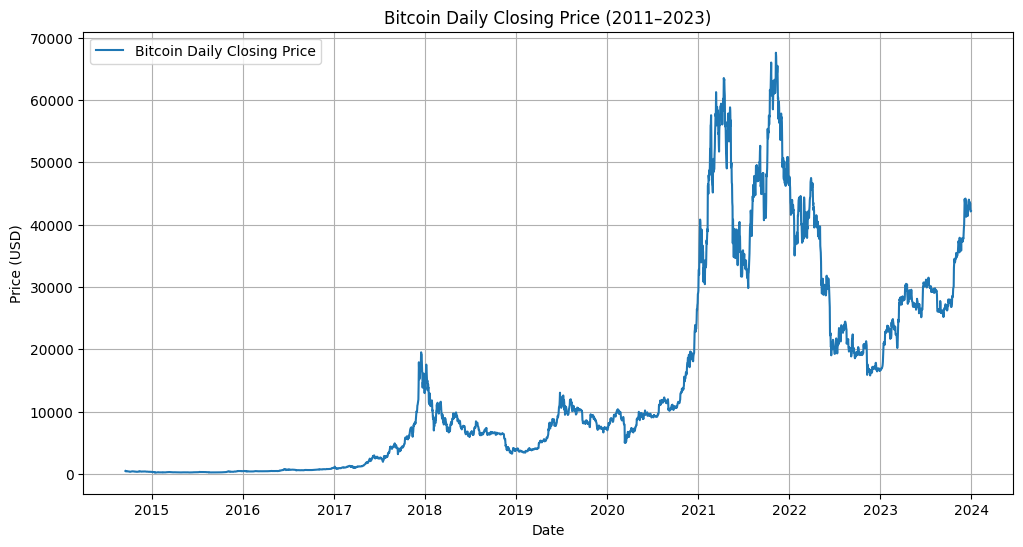

In [2]:
# --- Cell 1: Load Bitcoin Price Data from Yahoo Finance ---

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Download daily Bitcoin price data (you can adjust the time period here)
btc_data = yf.download('BTC-USD', start='2011-01-01', end='2023-12-31', progress=False)

# Inspect the first few rows of the data
print(btc_data.head())

# Plot the closing price
plt.figure(figsize=(12, 6))
plt.plot(btc_data.index, btc_data['Close'], label="Bitcoin Daily Closing Price")
plt.title("Bitcoin Daily Closing Price (2011–2023)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.show()


ADF Statistic: -1.3123192227603524
p-value: 0.6235175776292388
Critical Values: {'1%': -3.432296549639788, '5%': -2.8624000722521807, '10%': -2.567227833288095}
The time series is non-stationary (p-value > 0.05).


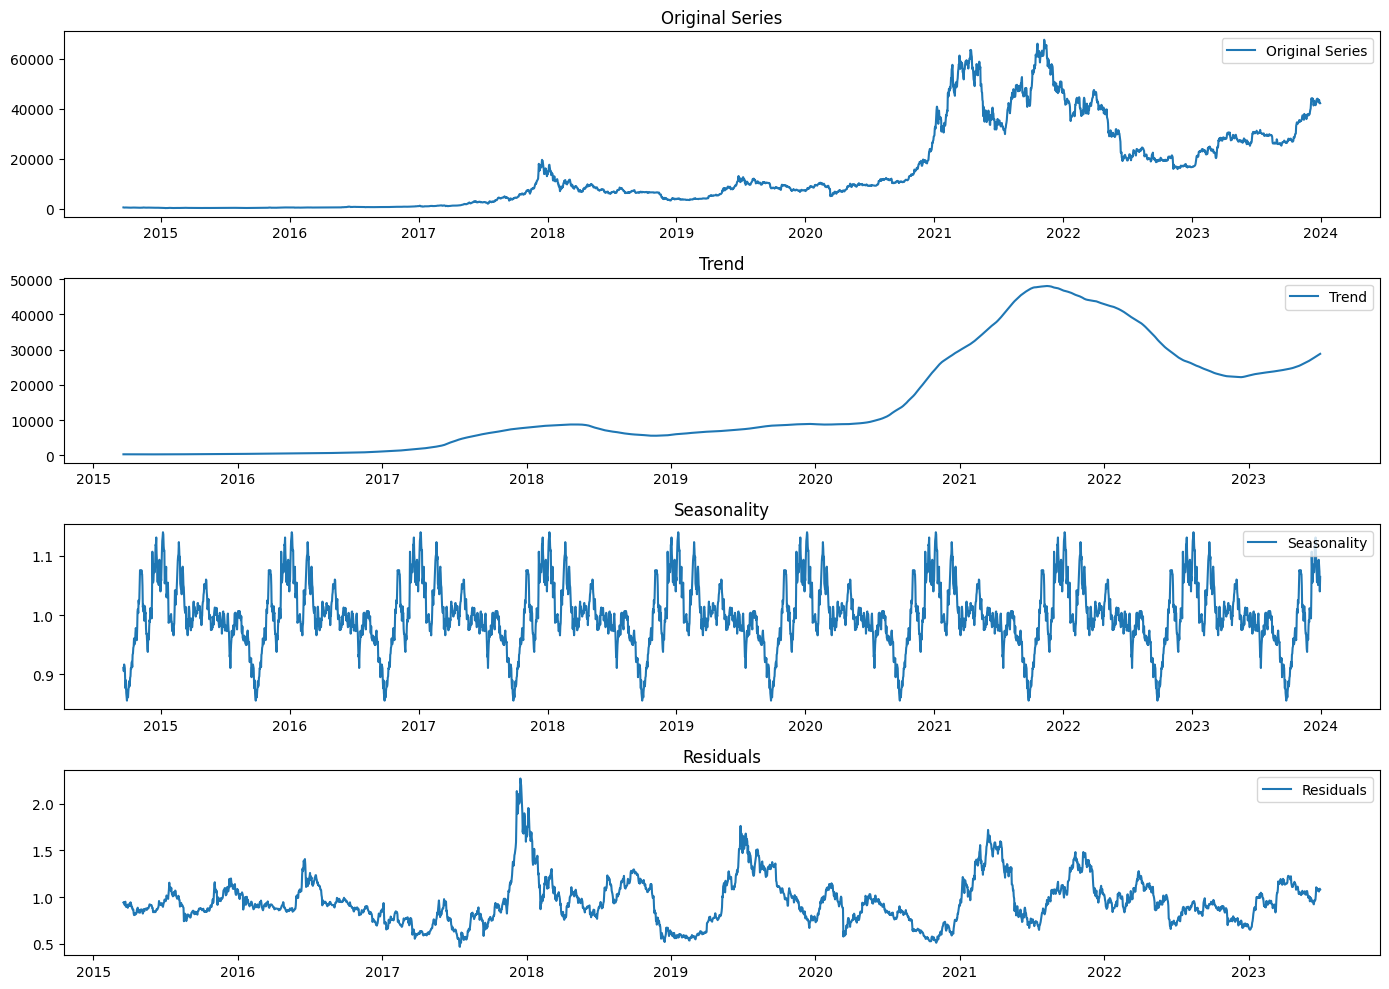

In [3]:
# --- Cell 2: Stationarity Test & Decompose Bitcoin Data ---

import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

# --- 1. Stationarity Test (Augmented Dickey-Fuller test) ---
result = adfuller(btc_data['Close'])

print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
print(f"Critical Values: {result[4]}")

# Interpretation of the ADF Test
if result[1] < 0.05:
    print("The time series is stationary (p-value < 0.05).")
else:
    print("The time series is non-stationary (p-value > 0.05).")

# --- 2. Decomposition of the time series ---
# Decompose the series (using multiplicative model for Bitcoin price)
decomposition = seasonal_decompose(btc_data['Close'], model='multiplicative', period=365)

# Plot the decomposed components
plt.figure(figsize=(14, 10))

plt.subplot(411)
plt.plot(btc_data.index, btc_data['Close'], label='Original Series')
plt.title("Original Series")
plt.legend()

plt.subplot(412)
plt.plot(btc_data.index, decomposition.trend, label='Trend')
plt.title("Trend")
plt.legend()

plt.subplot(413)
plt.plot(btc_data.index, decomposition.seasonal, label='Seasonality')
plt.title("Seasonality")
plt.legend()

plt.subplot(414)
plt.plot(btc_data.index, decomposition.resid, label='Residuals')
plt.title("Residuals")
plt.legend()

plt.tight_layout()
plt.show()


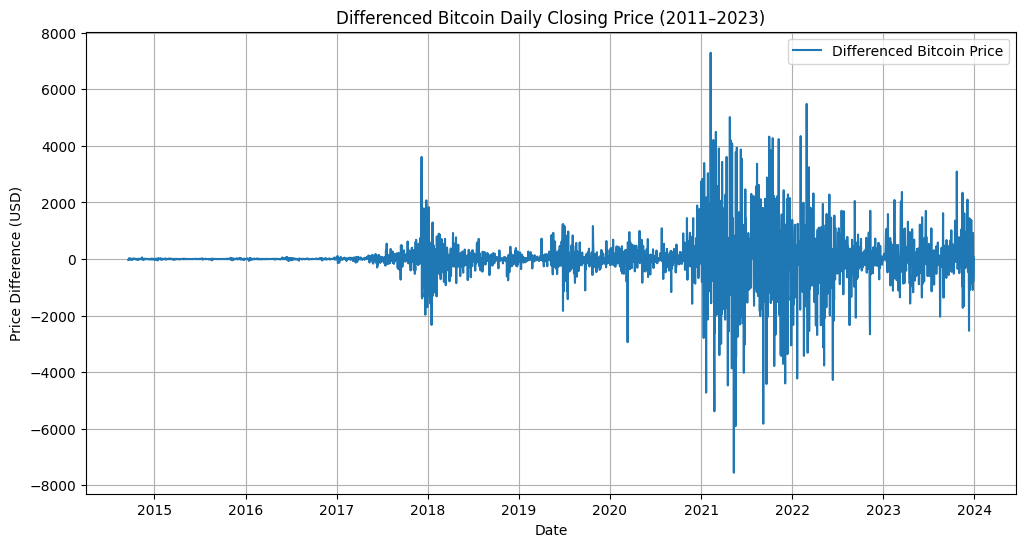

ADF Statistic (Differenced): -9.735304233002033
p-value (Differenced): 8.782621585162013e-17
Critical Values: {'1%': -3.432296549639788, '5%': -2.8624000722521807, '10%': -2.567227833288095}
The differenced series is stationary (p-value < 0.05).


In [4]:
# --- Cell 3: First Differencing to Remove Trend ---

# Apply first differencing to remove the trend
btc_data_diff = btc_data['Close'].diff().dropna()

# Plot the differenced series
plt.figure(figsize=(12, 6))
plt.plot(btc_data_diff.index, btc_data_diff, label="Differenced Bitcoin Price")
plt.title("Differenced Bitcoin Daily Closing Price (2011–2023)")
plt.xlabel("Date")
plt.ylabel("Price Difference (USD)")
plt.grid(True)
plt.legend()
plt.show()

# --- ADF Test on Differenced Series to Check for Stationarity ---
result_diff = adfuller(btc_data_diff)

print(f"ADF Statistic (Differenced): {result_diff[0]}")
print(f"p-value (Differenced): {result_diff[1]}")
print(f"Critical Values: {result_diff[4]}")

# Interpretation of the ADF Test for Differenced Series
if result_diff[1] < 0.05:
    print("The differenced series is stationary (p-value < 0.05).")
else:
    print("The differenced series is still non-stationary (p-value > 0.05).")


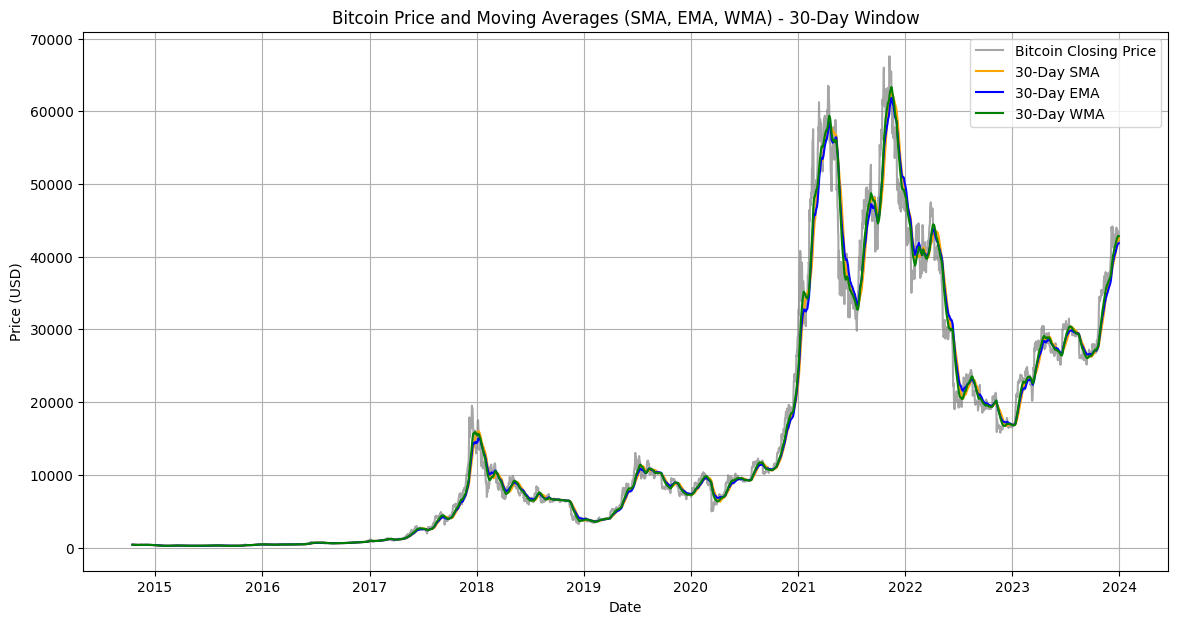

In [5]:
# --- Cell: Calculate and Plot SMA, EMA, WMA for Bitcoin Data with MultiIndex Handling ---

# Calculate the 30-day Simple Moving Average (SMA)
btc_data[('SMA_30', '')] = btc_data[('Close', 'BTC-USD')].rolling(window=30).mean()

# Calculate the 30-day Exponential Moving Average (EMA)
btc_data[('EMA_30', '')] = btc_data[('Close', 'BTC-USD')].ewm(span=30, adjust=False).mean()

# Calculate the 30-day Weighted Moving Average (WMA)
weights = np.arange(1, 31)  # Create weights (1 to 30)
btc_data[('WMA_30', '')] = btc_data[('Close', 'BTC-USD')].rolling(window=30).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)

# Drop rows where the moving averages are NaN (for the first 29 rows)
btc_data_clean = btc_data.dropna(subset=[('SMA_30', ''), ('EMA_30', ''), ('WMA_30', '')])

# Plot the original data and all three moving averages (SMA, EMA, WMA)
plt.figure(figsize=(14, 7))
plt.plot(btc_data_clean.index, btc_data_clean[('Close', 'BTC-USD')], label='Bitcoin Closing Price', color='gray', alpha=0.7)
plt.plot(btc_data_clean.index, btc_data_clean[('SMA_30', '')], label='30-Day SMA', color='orange')
plt.plot(btc_data_clean.index, btc_data_clean[('EMA_30', '')], label='30-Day EMA', color='blue')
plt.plot(btc_data_clean.index, btc_data_clean[('WMA_30', '')], label='30-Day WMA', color='green')

# Formatting the plot
plt.title("Bitcoin Price and Moving Averages (SMA, EMA, WMA) - 30-Day Window")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


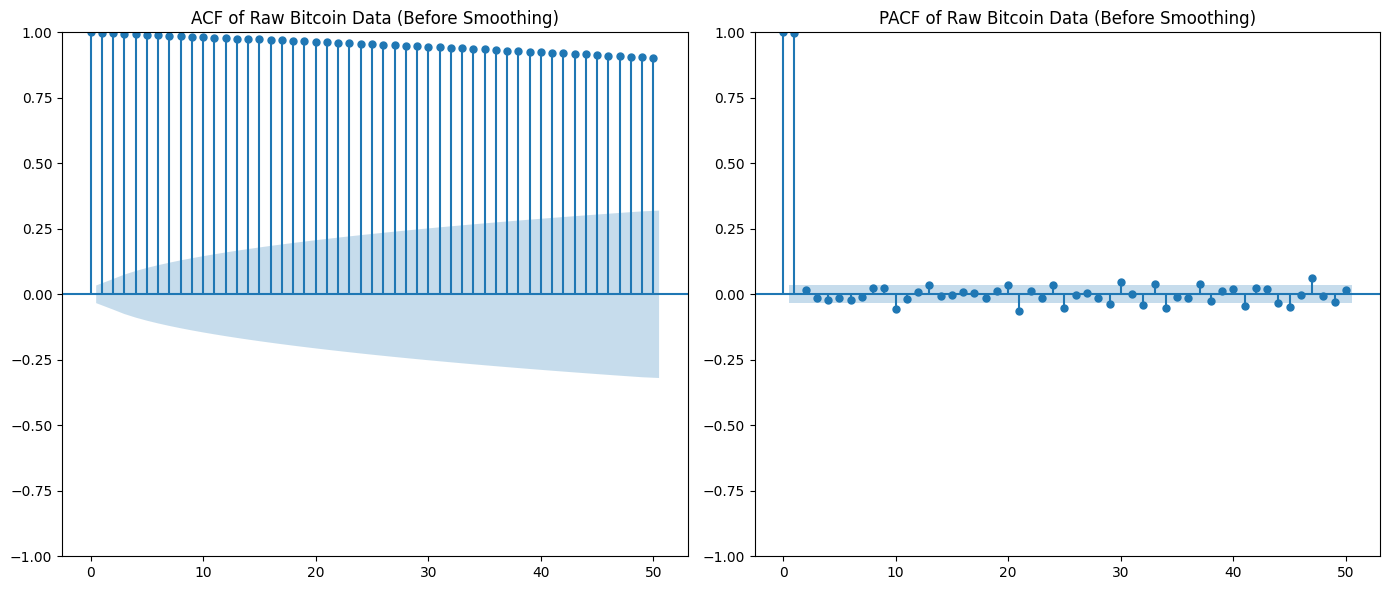

In [6]:
# --- Cell: ACF/PACF on Raw Bitcoin Data (Before Smoothing) ---

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Extract the raw closing price (Bitcoin)
raw_btc_data = btc_data[('Close', 'BTC-USD')]

# Plot the ACF for the raw Bitcoin closing price
plt.figure(figsize=(14, 6))
plt.subplot(121)
plot_acf(raw_btc_data, lags=50, ax=plt.gca())
plt.title("ACF of Raw Bitcoin Data (Before Smoothing)")

# Plot the PACF for the raw Bitcoin closing price
plt.subplot(122)
plot_pacf(raw_btc_data, lags=50, ax=plt.gca())
plt.title("PACF of Raw Bitcoin Data (Before Smoothing)")

plt.tight_layout()
plt.show()


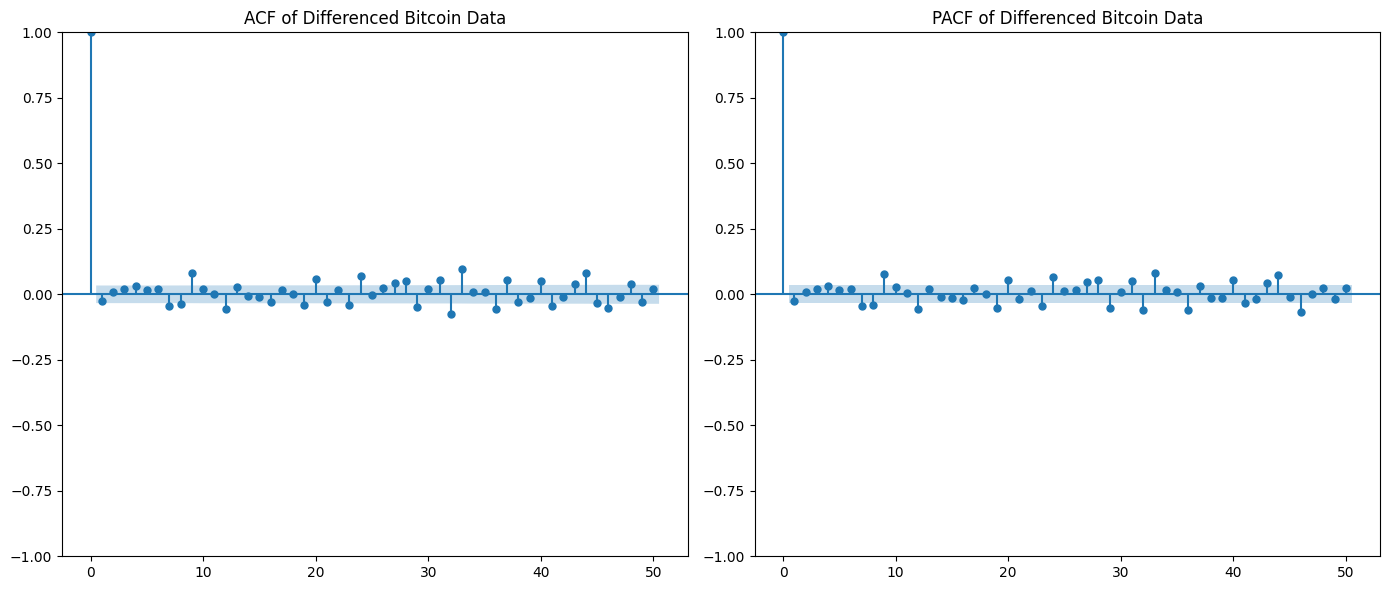

In [7]:
# --- Cell: ACF/PACF on Differenced Raw Bitcoin Data ---

# Apply first differencing to remove the trend
btc_data_diff = raw_btc_data.diff().dropna()

# Plot the ACF for the differenced Bitcoin closing price
plt.figure(figsize=(14, 6))
plt.subplot(121)
plot_acf(btc_data_diff, lags=50, ax=plt.gca())
plt.title("ACF of Differenced Bitcoin Data")

# Plot the PACF for the differenced Bitcoin closing price
plt.subplot(122)
plot_pacf(btc_data_diff, lags=50, ax=plt.gca())
plt.title("PACF of Differenced Bitcoin Data")

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                SARIMAX Results                                 
Dep. Variable:     ('Close', 'BTC-USD')   No. Observations:                 3392
Model:                   ARIMA(1, 1, 1)   Log Likelihood              -27397.995
Date:                  Sun, 07 Dec 2025   AIC                          54801.990
Time:                          18:27:11   BIC                          54820.376
Sample:                      09-17-2014   HQIC                         54808.562
                           - 12-30-2023                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1049      0.323     -0.324      0.746      -0.739       0.529
ma.L1          0.0782      0.325      0.241      0.810      -0.558       0.714
sigma2      6.108e+05   4947.650    

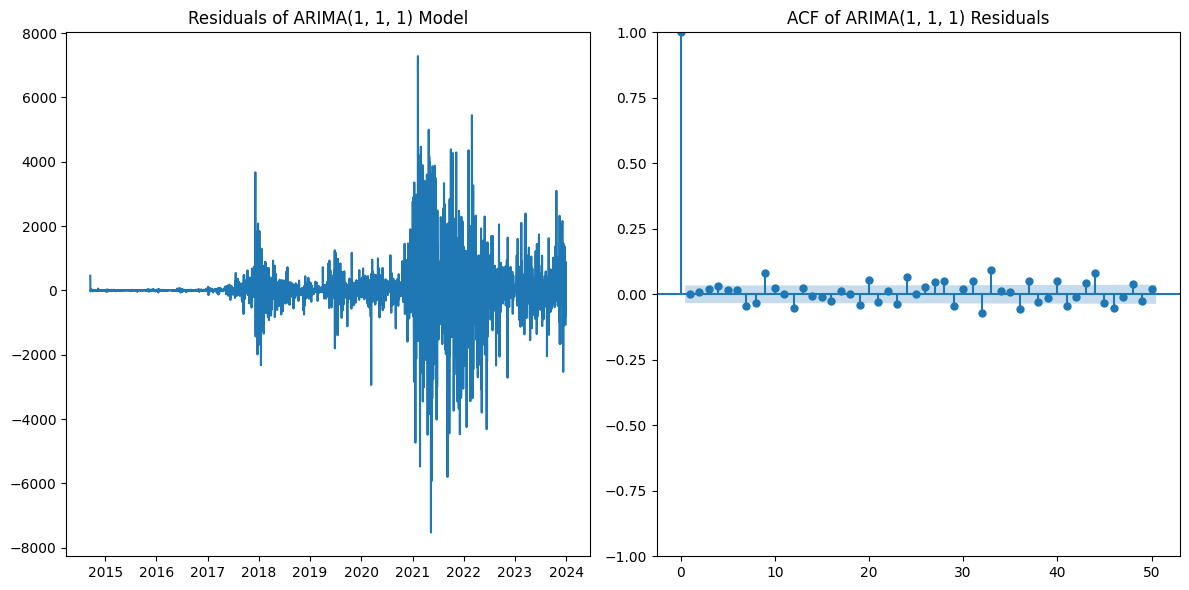

In [8]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model (1, 1, 1)
arima_model = ARIMA(btc_data['Close', 'BTC-USD'], order=(1, 1, 1))
arima_result = arima_model.fit()

# Print the ARIMA model summary
print(arima_result.summary())

# Plot the residuals of the ARIMA model
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.plot(arima_result.resid)
plt.title("Residuals of ARIMA(1, 1, 1) Model")

plt.subplot(122)
plot_acf(arima_result.resid, lags=50, ax=plt.gca())
plt.title("ACF of ARIMA(1, 1, 1) Residuals")
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:              ('Close', 'BTC-USD')   No. Observations:                 3392
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -27360.893
Date:                           Sun, 07 Dec 2025   AIC                          54731.785
Time:                                   18:27:19   BIC                          54762.419
Sample:                               09-17-2014   HQIC                         54742.737
                                    - 12-30-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9987      0.021    -47.541      0.000      -1.040      -0.958
ma.L1          0.9985      0.022     45.784

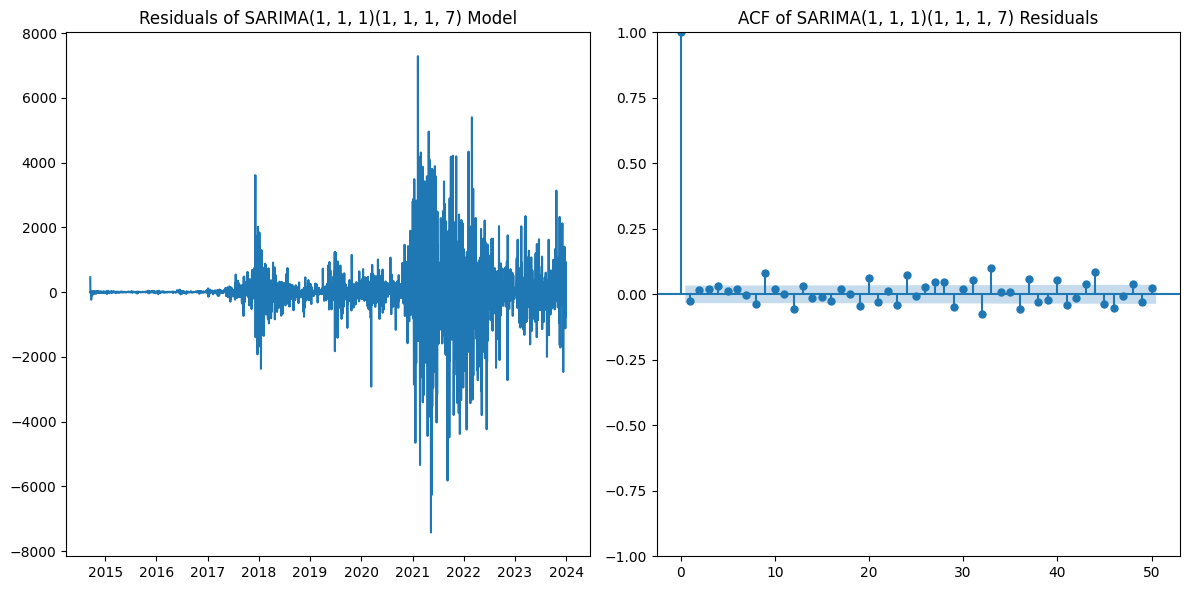

In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA(1, 1, 1)(1, 1, 1, 7) model
sarima_model = SARIMAX(btc_data['Close', 'BTC-USD'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
sarima_result = sarima_model.fit()

# Print the SARIMA model summary
print(sarima_result.summary())

# Plot the residuals of the SARIMA model
plt.figure(figsize=(12, 6))

# Plot the residuals
plt.subplot(121)
plt.plot(sarima_result.resid)
plt.title("Residuals of SARIMA(1, 1, 1)(1, 1, 1, 7) Model")

# Plot the ACF of the residuals
plt.subplot(122)
plot_acf(sarima_result.resid, lags=50, ax=plt.gca())
plt.title("ACF of SARIMA(1, 1, 1)(1, 1, 1, 7) Residuals")

plt.tight_layout()
plt.show()


In [10]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Selecting the 'Close' price from the Bitcoin data
btc_data_close = btc_data[('Close', 'BTC-USD')].values.reshape(-1, 1)

# Normalizing the 'Close' price data using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
btc_data_scaled = scaler.fit_transform(btc_data_close)

# Displaying the normalized data
print(f"Scaled Bitcoin 'Close' data: {btc_data_scaled[:5]}")


Scaled Bitcoin 'Close' data: [[0.00414359]
 [0.00365546]
 [0.00321557]
 [0.00342492]
 [0.0032753 ]]


In [11]:
def create_dataset(data, look_back=30):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i, 0])  # Using 'look_back' previous days
        y.append(data[i, 0])  # The target is the next value
    return np.array(X), np.array(y)

look_back = 30  # We will use the previous 30 days for prediction
X, y = create_dataset(btc_data_scaled, look_back)

# Reshaping X to be 3D for LSTM and GRU (samples, time steps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)

print(f"Input data shape: {X.shape}")
print(f"Output data shape: {y.shape}")


Input data shape: (3362, 30, 1)
Output data shape: (3362,)


In [12]:
    # Train-test split (80% for training, 20% for testing)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training data size: {X_train.shape[0]}")
print(f"Testing data size: {X_test.shape[0]}")


Training data size: 2689
Testing data size: 673


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Building the LSTM model
model_lstm = Sequential()

# LSTM layer
model_lstm.add(LSTM(units=50, return_sequences=False, input_shape=(X_train.shape[1], 1)))

# Dropout to prevent overfitting
model_lstm.add(Dropout(0.2))

# Dense layer for output
model_lstm.add(Dense(units=1))

# Compile the model
model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Training the model
history_lstm = model_lstm.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Model summary
model_lstm.summary()


2025-12-07 18:27:43.269583: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765132063.523996      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765132063.594860      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,355 (122.48 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,904 (81.66 KB)

In [14]:
from tensorflow.keras.layers import GRU

# Building the GRU model
model_gru = Sequential()

# GRU layer
model_gru.add(GRU(units=50, return_sequences=False, input_shape=(X_train.shape[1], 1)))

# Dropout to prevent overfitting
model_gru.add(Dropout(0.2))

# Dense layer for output
model_gru.add(Dense(units=1))

# Compile the model
model_gru.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Training the model
history_gru = model_gru.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Model summary
model_gru.summary()


Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0161 - val_loss: 3.0006e-04
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0012 - val_loss: 3.3280e-04
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0010 - val_loss: 2.3744e-04
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 8.6928e-04 - val_loss: 2.4820e-04
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 9.1893e-04 - val_loss: 2.9874e-04
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 8.5273e-04 - val_loss: 2.3791e-04
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 7.8076e-04 - val_loss: 2.4709e-04
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.3697e-04 - val_loss: 3.7167e-04
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.9770e-04 - val_loss: 2.1500e-04
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.6805e-04 - val_loss: 3.0964e-04


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,005 (93.77 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,004 (62.52 KB)

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predicting the values using LSTM and GRU
y_pred_lstm = model_lstm.predict(X_test)
y_pred_gru = model_gru.predict(X_test)

# Inverse scaling to get the original values
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_lstm_original = scaler.inverse_transform(y_pred_lstm)
y_pred_gru_original = scaler.inverse_transform(y_pred_gru)

# Calculating MSE and MAE
mse_lstm = mean_squared_error(y_test_original, y_pred_lstm_original)
mae_lstm = mean_absolute_error(y_test_original, y_pred_lstm_original)

mse_gru = mean_squared_error(y_test_original, y_pred_gru_original)
mae_gru = mean_absolute_error(y_test_original, y_pred_gru_original)

print(f"LSTM - MSE: {mse_lstm}, MAE: {mae_lstm}")
print(f"GRU - MSE: {mse_gru}, MAE: {mae_gru}")


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
LSTM - MSE: 2542194.832129341, MAE: 1237.122240086367
GRU - MSE: 1406149.2504715004, MAE: 949.5119335066864


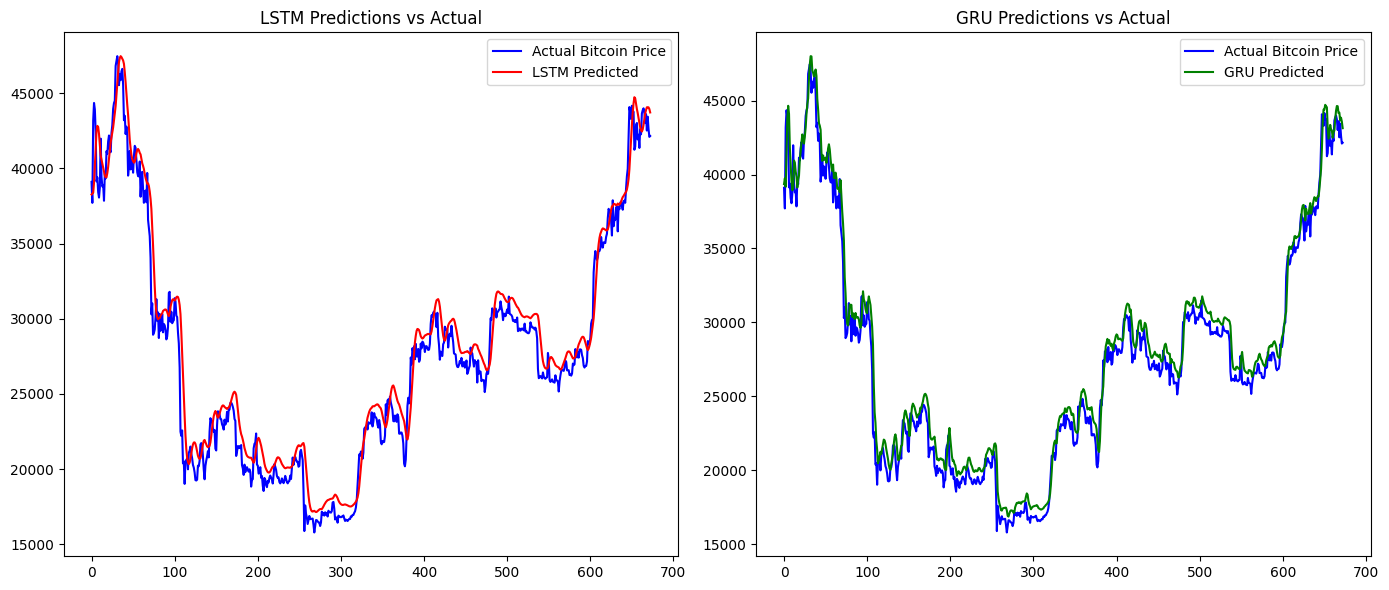

In [16]:
# Plotting the predictions vs actual values for LSTM and GRU
plt.figure(figsize=(14, 6))

# LSTM Plot
plt.subplot(121)
plt.plot(y_test_original, label='Actual Bitcoin Price', color='blue')
plt.plot(y_pred_lstm_original, label='LSTM Predicted', color='red')
plt.title("LSTM Predictions vs Actual")
plt.legend()

# GRU Plot
plt.subplot(122)
plt.plot(y_test_original, label='Actual Bitcoin Price', color='blue')
plt.plot(y_pred_gru_original, label='GRU Predicted', color='green')
plt.title("GRU Predictions vs Actual")
plt.legend()

plt.tight_layout()
plt.show()
